In [29]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import train_test_split
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_squared_error, r2_score

In [30]:
student_data = pd.read_csv('../data/prepared_student_data.csv')
student_data.head()

,age,study_hours,study_seatings,social_media_hours,attendance,skill_hours,semester_gpa,cumulative_gpa,credits,family_income,...,skills_programming,skills_software_development,skills_web_development,interest_area_data_science,interest_area_hardware,interest_area_machine_learning,interest_area_networking,interest_area_other,interest_area_software,interest_area_ui/ux
0,24,3,2,5,90.0,2,2.68,3.15,75,25000,...,0,1,0,0,0,0,0,1,0,0
1,22,3,2,3,96.0,2,2.68,3.15,36,100000,...,0,0,1,0,0,0,0,1,0,0
2,21,3,3,3,80.0,1,2.68,3.15,50,50000,...,1,0,0,0,0,0,0,0,1,0
3,20,1,3,2,88.0,1,2.68,3.15,36,62488,...,1,0,0,0,0,0,0,0,0,0
4,22,3,1,2,80.0,1,2.68,3.15,36,50000,...,1,0,0,0,0,0,0,0,1,0


# Inferential

Question: Is there a credible difference in the average study hours between STEM and other majors in the population of all college students?

## Computation Process

In [31]:
student_data.head()

,age,study_hours,study_seatings,social_media_hours,attendance,skill_hours,semester_gpa,cumulative_gpa,credits,family_income,...,skills_programming,skills_software_development,skills_web_development,interest_area_data_science,interest_area_hardware,interest_area_machine_learning,interest_area_networking,interest_area_other,interest_area_software,interest_area_ui/ux
0,24,3,2,5,90.0,2,2.68,3.15,75,25000,...,0,1,0,0,0,0,0,1,0,0
1,22,3,2,3,96.0,2,2.68,3.15,36,100000,...,0,0,1,0,0,0,0,1,0,0
2,21,3,3,3,80.0,1,2.68,3.15,50,50000,...,1,0,0,0,0,0,0,0,1,0
3,20,1,3,2,88.0,1,2.68,3.15,36,62488,...,1,0,0,0,0,0,0,0,0,0
4,22,3,1,2,80.0,1,2.68,3.15,36,50000,...,1,0,0,0,0,0,0,0,1,0


In [33]:
# getting scholarship yes count
scholarship_count = student_data['scholarship_yes'].sum()
no_scholarship_count = len(student_data) - scholarship_count 
print(f"Number of students with scholarship: {scholarship_count}, without scholarship: {no_scholarship_count}")

Number of students with scholarship: 523, without scholarship: 670


Based on the normal-normal conjugate, 

Posterior Distribution of Parameter: 
$$\theta | x \sim N\left( \frac{\frac{n\bar{x}}{\sigma^2} + \frac{\mu}{\tau^2}}{\frac{n}{\sigma^2} + \frac{1}{\tau^2}}, \frac{1}{\frac{n}{\sigma^2} + \frac{1}{\tau^2}} \right)$$

Bayesian Point Estimate: 
$$\hat{\theta}_{BE} = \left( \frac{n\tau^2}{n\tau^2 + \sigma^2} \right)\bar{x} + \left( \frac{\sigma^2}{n\tau^2 + \sigma^2} \right)\mu$$

Where: 
- $\bar{x}$: Sample Mean (The observed difference in our dataset)
- $n$: Sample Size.$\sigma^2$: Data Variance (Assumed known from the sample)
- $\mu$: Prior Mean (Our initial belief, e.g., $0$ for no difference)
- $\tau^2$: Prior Variance (How certain we are of our prior belief)
- $\frac{1}{\sigma^2}$: Sample Precision (inverse of variance)
- $\frac{1}{\tau^2}$: Prior Precision (inverse of variance)

Finding parameter (diff between scholarship and no scholarship GPA)


In [34]:
#scholarship_students = student_data[student_data['scholarship'] == 'Yes']
scholarship_students = student_data[student_data['scholarship_yes'] == 1]
no_scholarship_students = student_data[student_data['scholarship_yes'] == 0]
mean_scholarship_gpa = scholarship_students['cumulative_gpa'].mean()
mean_no_scholarship_gpa = no_scholarship_students['cumulative_gpa'].mean()
gpa_diff = mean_scholarship_gpa - mean_no_scholarship_gpa
print(f"Mean GPA for scholarship students: {mean_scholarship_gpa:.2f}")
print(f"Mean GPA for non-scholarship students: {mean_no_scholarship_gpa:.2f}")
print(f"Difference in mean GPA: {gpa_diff:.2f}")

Mean GPA for scholarship students: 3.21
Mean GPA for non-scholarship students: 3.13
Difference in mean GPA: 0.07


Finding values for variables

In [35]:
x_bar = gpa_diff
n = len(student_data)
# using sample variance as an estimate for population variance
sigma_sq = student_data['cumulative_gpa'].var()

For our prior distribution we assume there is no difference between cumulative GPA for students on scholarship and not on scholarship. This means that our prior belief is there is no effect of scholarship status on cumulative GPA. Because of this we use $\mu$ = 0 and $\sigma$ = 0.5.  

In [36]:
# setting prior beliefs
mu = 0 
tau_sq = 0.5**2 

# calculating precision (1 / Variance)
prior_precision = 1 / tau_sq
sample_precision = n / sigma_sq
posterior_precision = prior_precision + sample_precision

Computing posterior metrics 
- post_mean = [(sample_mean * sample_prec) + (prior_mean * prior_prec)] / total_prec

In [37]:
# mean
post_mu = ((x_bar * sample_precision) + (mu * prior_precision) ) / posterior_precision

# variance/std
post_var = 1 / posterior_precision
post_std = np.sqrt(post_var)

Now that posterior metrics have been calculated we can compute the credible interval

In [38]:
lower, upper = norm.interval(0.95, loc=post_mu, scale=post_std)

print(f"Posterior Mean: {post_mu:.4f}")
print(f"95% Credible Interval: ({lower:.4f}, {upper:.4f})")

Posterior Mean: 0.0706
95% Credible Interval: (0.0281, 0.1132)


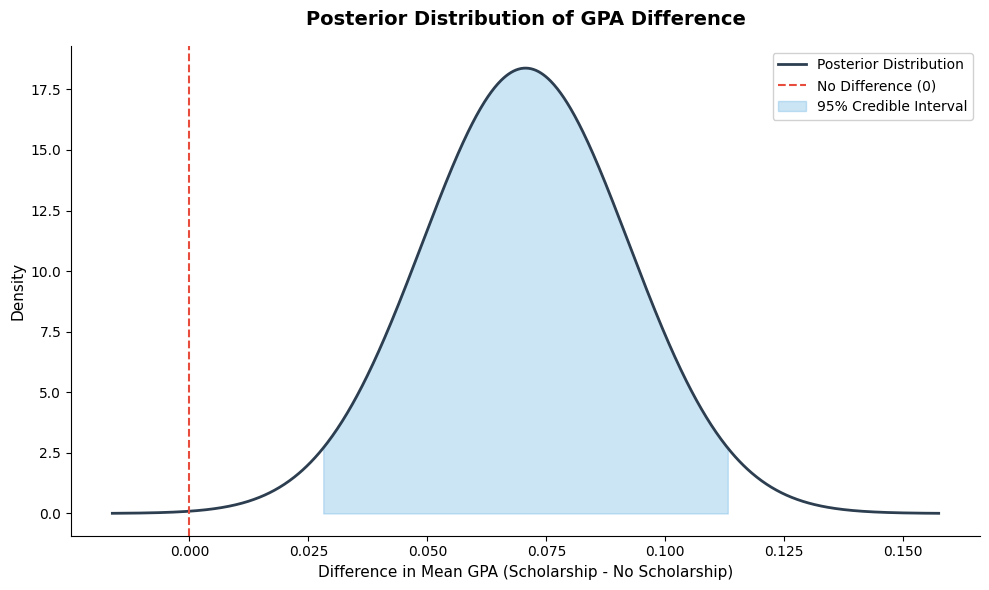

In [39]:
x = np.linspace(post_mu - 4*post_std, post_mu + 4*post_std, 1000)
y = norm.pdf(x, loc=post_mu, scale=post_std)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Posterior Distribution', color='#2c3e50', linewidth=2)
plt.axvline(x=0, color='#e74c3c', linestyle='--', linewidth=1.5, label='No Difference (0)')
plt.fill_between(x, y, where=(x >= lower) & (x <= upper), color='#3498db', alpha=0.25, label='95% Credible Interval')
plt.title('Posterior Distribution of GPA Difference', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Difference in Mean GPA (Scholarship - No Scholarship)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(framealpha=0.9, fontsize=10)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Interpretation

The posterior mean we found was 0.07 and the 95% credible interval was [0.028, 0.113]. Since the 95% credible interval does not contain 0 we conclude that there is an effect of scholarship status on cumulative GPA for college students. This means that there is a 95% posterior probability that the true difference of cumulative GPA for college students who are on scholarship vs. those who are not on scholarship (scholarship - non scholarship) is between 0.028 and 0.113. These findings show that there is strong posterior evidence that students on scholarship have higher GPAs.

# Predictive
To what extent can a Bayesian linear regression model accurately forecast individual student GPAs using scholarship status, study hours, and demographic factors as predictors?

## Building Model

In [40]:
student_data.head()

,age,study_hours,study_seatings,social_media_hours,attendance,skill_hours,semester_gpa,cumulative_gpa,credits,family_income,...,skills_programming,skills_software_development,skills_web_development,interest_area_data_science,interest_area_hardware,interest_area_machine_learning,interest_area_networking,interest_area_other,interest_area_software,interest_area_ui/ux
0,24,3,2,5,90.0,2,2.68,3.15,75,25000,...,0,1,0,0,0,0,0,1,0,0
1,22,3,2,3,96.0,2,2.68,3.15,36,100000,...,0,0,1,0,0,0,0,1,0,0
2,21,3,3,3,80.0,1,2.68,3.15,50,50000,...,1,0,0,0,0,0,0,0,1,0
3,20,1,3,2,88.0,1,2.68,3.15,36,62488,...,1,0,0,0,0,0,0,0,0,0
4,22,3,1,2,80.0,1,2.68,3.15,36,50000,...,1,0,0,0,0,0,0,0,1,0


In [41]:
student_data = student_data.dropna()
X = student_data.drop(['cumulative_gpa', 'semester_gpa'], axis=1)
y = student_data['cumulative_gpa']

In [42]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fitting bayesian ridge model
model = BayesianRidge()
model.fit(X_train, y_train)

# Generating predictions and uncertainty estimates
y_pred, y_std = model.predict(X_test, return_std=True)

# Evaluating
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R-squared Score: {r2:.4f}")

Root Mean Squared Error: 0.6066
R-squared Score: 0.1051


## Prediction Interval

In [43]:
# Select a random sample student from test set 
sample_index = np.random.choice(len(y_pred))
individual_pred = y_pred[sample_index]
individual_std = y_std.iloc[sample_index]

# Calculate the 95% Prediction Interval
lower_pi = individual_pred - (1.96 * individual_std)
upper_pi = individual_pred + (1.96 * individual_std)

print(f"Prediction for Student {sample_index}:")
print(f"Expected Cumulative GPA: {individual_pred:.2f}")
print(f"95% Prediction Interval: ({lower_pi:.2f}, {upper_pi:.2f})")
print(f"Actual GPA: {y_test.iloc[sample_index]:.2f}")

Prediction for Student 176:
Expected Cumulative GPA: 3.00
95% Prediction Interval: (1.37, 4.64)
Actual GPA: 3.80


Generally, our prediction intervals are fairly wide and not very informative. This is because the model performed poorly.